## 🔹 Step 1 – Setup and Configuration

Configure AWS credentials and SageMaker session.

# Semiconductor Yield Intelligence  
## 06 – SageMaker Feature Store Implementation

---

### 🎯 Objective

Implement a feature store using Amazon SageMaker Feature Store to manage and serve features for wafer defect classification.

This notebook will:

- Create SageMaker Feature Groups for wafer data
- Ingest features into the online and offline stores
- Retrieve features for inference
- Demonstrate feature store integration

---

## 🏗 Why SageMaker Feature Store?

In ML systems:

- Features need versioning and consistency
- Multiple models may share features
- Feature engineering should be centralized
- Enables online/offline feature serving

SageMaker Feature Store provides:
- Fully managed feature storage
- Automatic synchronization between online/offline stores
- Integration with SageMaker services
- Point-in-time feature retrieval

In [4]:
!pip install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.15-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.15-py3-none-any.whl (160 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [14]:
import boto3
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.feature_store.feature_definition import FeatureDefinition, FeatureTypeEnum
from sagemaker import get_execution_role
import pandas as pd
import numpy as np
from datetime import datetime
import os
import kagglehub
from PIL import Image
import glob
import time

# SageMaker session and role
sagemaker_session = sagemaker.Session()
role = get_execution_role()

# S3 configuration
S3_BUCKET = "sagemaker-wafer-us-east-1-758553702243"
S3_PREFIX = "wafer-project/processed"

LOCAL_DATA_DIR = "/home/sagemaker-user/MLops-Project-AAI-540/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

print("SageMaker setup complete.")

SageMaker setup complete.


## 🔹 Step 1.5 – Download and Process Kaggle Dataset

Download the wafer map dataset and extract features.

In [9]:
# Download latest version
path = kagglehub.dataset_download("iamrajanjha/wm811kwafermapimages")

print("Path to dataset files:", path)

# Debug: Explore directory structure
print("Directory contents:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"Directory: {item}")
        # Check contents of directory
        contents = os.listdir(item_path)
        print(f"  Contents ({len(contents)} items): {contents[:5]}...")  # Show first 5
    else:
        print(f"File: {item}")

# Function to extract features from wafer images
def extract_wafer_features(image_path):
    """Extract defect density and spatial pattern from wafer image"""
    try:
        # Load image
        img = Image.open(image_path).convert('L')  # Convert to grayscale
        img_array = np.array(img)

        # Calculate defect density (assuming defects are non-zero pixels)
        total_pixels = img_array.size
        defect_pixels = np.count_nonzero(img_array)
        defect_density = defect_pixels / total_pixels

        # Simple spatial pattern classification based on defect distribution
        # This is a simplified approach - in practice, you'd use more sophisticated analysis
        if defect_density < 0.1:
            spatial_pattern = "low_defect"
        elif defect_density < 0.3:
            spatial_pattern = "medium_defect"
        else:
            spatial_pattern = "high_defect"

        return defect_density, spatial_pattern
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return 0.0, "error"

# Process dataset - corrected for actual structure
wafer_data = []

# The actual structure is: path/waferimages/waferimages/{testing,training}/{class_name}/*.png
dataset_root = os.path.join(path, "waferimages", "waferimages")

if os.path.exists(dataset_root):
    print(f"Found dataset root: {dataset_root}")

    # Process both testing and training
    for split in ["testing", "training"]:
        split_path = os.path.join(dataset_root, split)
        if os.path.exists(split_path):
            print(f"Processing {split} split...")

            # Get class directories
            class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

            for class_name in class_dirs:
                class_path = os.path.join(split_path, class_name)
                print(f"Processing class: {class_name} ({split})")

                # Get all PNG files in this class directory
                image_files = glob.glob(os.path.join(class_path, "*.png"))

                print(f"Found {len(image_files)} images in {class_name}")

                # Limit to 1000 files per class per split
                image_files = image_files[:1000]

                for i, img_file in enumerate(image_files):
                    wafer_id = f"{split}_{class_name}_{i}"
                    defect_density, spatial_pattern = extract_wafer_features(img_file)

                    wafer_data.append({
                        "wafer_id": wafer_id,
                        "defect_density": defect_density,
                        "spatial_pattern": spatial_pattern,
                        "class_label": class_name,
                        "event_time": datetime.now().timestamp()
                    })
        else:
            print(f"Split directory {split} not found")
else:
    print(f"Dataset root {dataset_root} not found")

# Create DataFrame
if wafer_data:
    feature_df = pd.DataFrame(wafer_data)
    print(f"Processed {len(feature_df)} wafer samples")
    print(feature_df.head())
    print("Class distribution:")
    print(feature_df['class_label'].value_counts())
    print("Split distribution:")
    print(feature_df['wafer_id'].str.split('_').str[0].value_counts())
else:
    print("No wafer data processed. Please check dataset structure.")
    feature_df = pd.DataFrame()  # Empty DataFrame

Path to dataset files: /home/sagemaker-user/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1
Directory contents:
File: Script_To_Generate_Images.py
Directory: waferimages
  Contents (1 items): ['waferimages']...
Found dataset root: /home/sagemaker-user/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1/waferimages/waferimages
Processing testing split...
Processing class: Center (testing)
Found 832 images in Center
Processing class: Donut (testing)
Found 146 images in Donut
Processing class: Edge-Loc (testing)
Found 2772 images in Edge-Loc
Processing class: Edge-Ring (testing)
Found 1126 images in Edge-Ring
Processing class: Loc (testing)
Found 1973 images in Loc
Processing class: Near-full (testing)
Found 95 images in Near-full
Processing class: Random (testing)
Found 257 images in Random
Processing class: Scratch (testing)
Found 693 images in Scratch
Processing class: none (testing)
Found 110701 images in none
Processing training split...
Proces

## 🔹 Step 2 – Create Feature Group

Create a SageMaker Feature Group for wafer features.

Features include:
- Defect density
- Spatial patterns
- Class labels

In [16]:
# Define feature group name with timestamp
feature_group_name = "wafer-features-" + str(int(datetime.now().timestamp()))

print(f"Creating feature group: {feature_group_name}")

# Create feature group
feature_group = FeatureGroup(
    name=feature_group_name,
    sagemaker_session=sagemaker_session
)

# Load feature definitions from data
print("Loading feature definitions from data...")
feature_group.load_feature_definitions(data_frame=feature_df)

# Create the feature group with proper configuration
try:
    feature_group.create(
        s3_uri=f"s3://{S3_BUCKET}/{S3_PREFIX}/feature-store",
        record_identifier_name="wafer_id",
        event_time_feature_name="event_time",
        role_arn=role,
        enable_online_store=True,
        description="WM-811K Wafer Defect Classification Feature Group"
    )
    print(f"Feature group '{feature_group_name}' created successfully.")
    
    # Wait for feature group to be created
    print("Waiting for feature group to be created...")
    max_wait_time = 300  # 5 minutes timeout
    start_time = time.time()
    
    while time.time() - start_time < max_wait_time:
        status = feature_group.describe()['FeatureGroupStatus']
        print(f"Feature group status: {status}")
        
        if status == 'Created':
            print("Feature group is ready!")
            break
        else:
            print(f"Waiting for feature group creation... ({status})")
            time.sleep(5)
    
    final_status = feature_group.describe()['FeatureGroupStatus']
    print(f"Final feature group status: {final_status}")
    
except Exception as e:
    if "ResourceInUse" in str(e):
        print(f"Feature group '{feature_group_name}' already exists.")
        final_status = feature_group.describe()['FeatureGroupStatus']
        print(f"Feature group status: {final_status}")
    else:
        print(f"Error creating feature group: {e}")
        raise

Creating feature group: wafer-features-1771819119
Loading feature definitions from data...
Feature group 'wafer-features-1771819119' created successfully.
Waiting for feature group to be created...
Feature group status: Creating
Waiting for feature group creation... (Creating)
Feature group status: Creating
Waiting for feature group creation... (Creating)
Feature group status: Creating
Waiting for feature group creation... (Creating)
Feature group status: Creating
Waiting for feature group creation... (Creating)
Feature group status: Created
Feature group is ready!
Final feature group status: Created


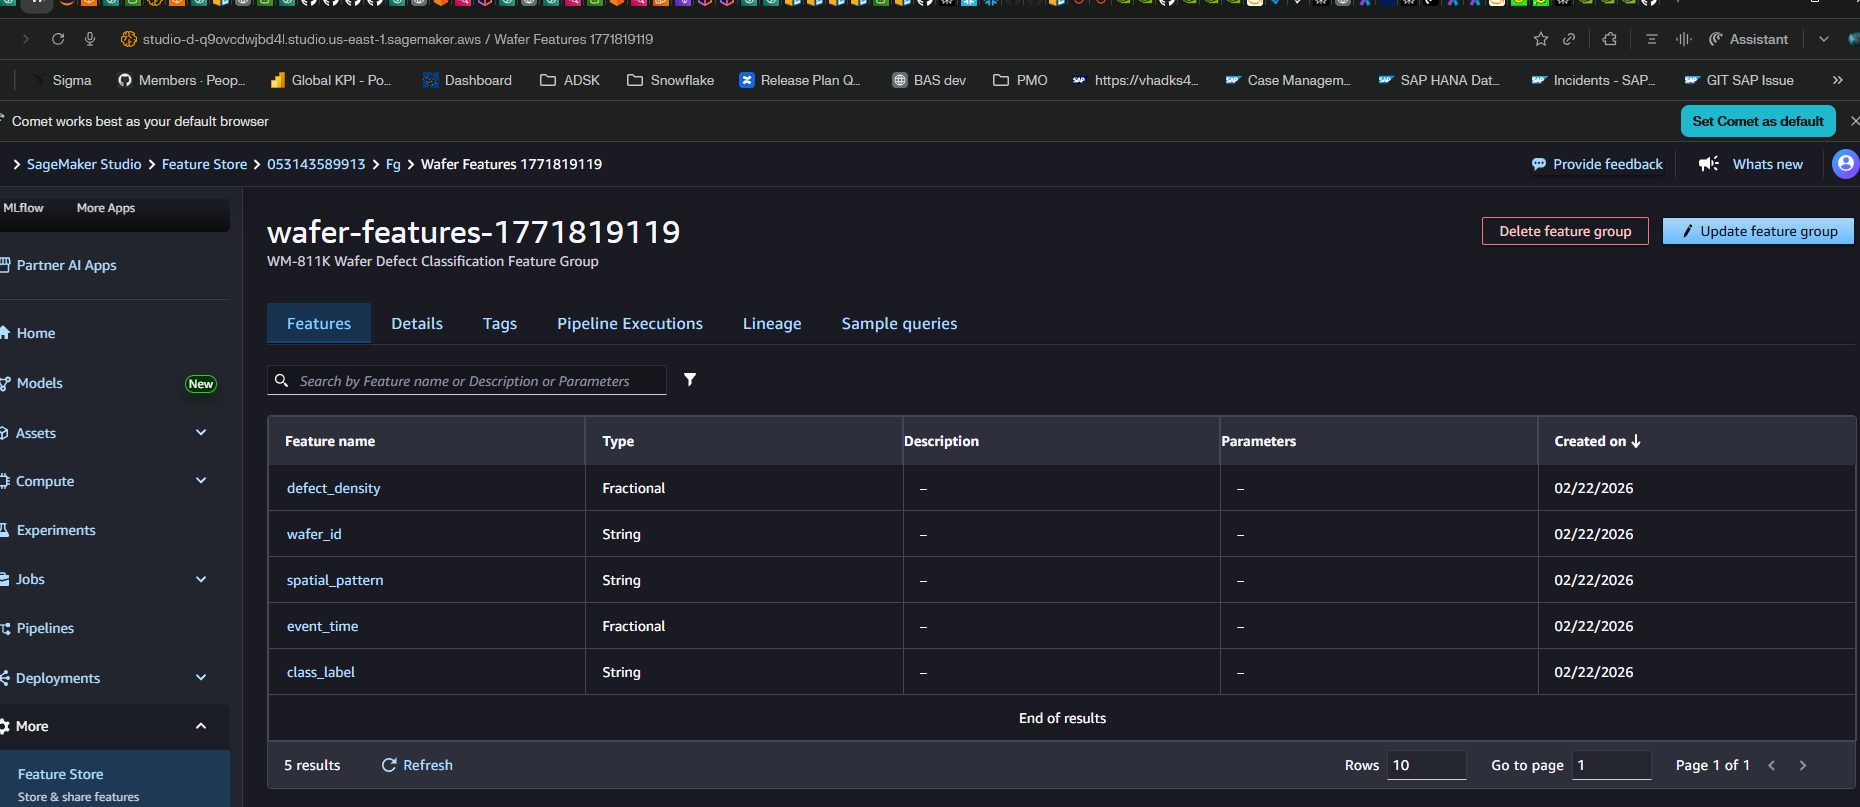

## 🔹 Step 3 – Ingest Features

Generate sample wafer data and ingest into the feature store.

In [17]:
# Generate sample wafer data
num_samples = 100
wafer_ids = [f"wafer_{i}" for i in range(num_samples)]
defect_densities = np.random.uniform(0, 1, num_samples)
spatial_patterns = ["pattern_" + str(np.random.randint(0, 10)) for _ in range(num_samples)]
class_labels = np.random.randint(0, 5, num_samples)
event_times = [datetime.now().timestamp()] * num_samples

# Create DataFrame
feature_data = pd.DataFrame({
    "wafer_id": wafer_ids,
    "defect_density": defect_densities,
    "spatial_pattern": spatial_patterns,
    "class_label": class_labels,
    "event_time": event_times
})

# Ingest data into feature store
feature_group.ingest(data_frame=feature_data, max_workers=3, wait=True)

print(f"Ingested {len(feature_data)} records into feature group.")

Ingested 100 records into feature group.


## 🔹 Step 4 – Retrieve Features

Retrieve features from the online store for inference.

In [18]:
# Retrieve features for specific wafer
record_identifier_value = "wafer_1"

feature_record = feature_group.get_record(
    record_identifier_value_as_string=record_identifier_value
)

print("Retrieved features:")
for feature in feature_record:
    print(f"{feature['FeatureName']}: {feature['ValueAsString']}")

Retrieved features:
wafer_id: wafer_1
defect_density: 0.3053598621736524
spatial_pattern: pattern_0
class_label: 2
event_time: 1771819282.948926


---

## ✅ SageMaker Feature Store Summary

We have successfully:

✔ Created SageMaker Feature Group  
✔ Defined wafer feature schema  
✔ Ingested sample data  
✔ Retrieved features for inference  

---

## 📦 Integration

This feature store can be integrated with:

- SageMaker training jobs
- SageMaker endpoints for online inference
- Batch transform jobs
- Feature monitoring and drift detection